In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0329.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0139.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0572_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0547_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0733.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0629_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0618_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0100.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenz

In [2]:
# ============================================================================
# B X-RAY CLASSIFICATION WITH HYBRID CNN-TRANSFORMER
# ============================================================================



In [6]:
# CELL 1: Install Required Packages
# ============================================================================
!pip install grad-cam timm -q


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [8]:
# CELL 2: Import Libraries
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision import models
import timm

from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, 
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Available GPUs: {torch.cuda.device_count()}")


Using device: cuda
GPU: Tesla P100-PCIE-16GB
Available GPUs: 1


In [9]:
# CELL 3: Configuration and Hyperparameters
# ============================================================================
class Config:
    # Paths
    DATA_PATH = '/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen'  # UPDATE THIS PATH
    
    # Image settings
    IMG_SIZE = 224
    BATCH_SIZE = 32
    
    # Model settings
    NUM_CLASSES = 2
    EMBEDDING_DIM = 768
    NUM_HEADS = 8
    NUM_TRANSFORMER_BLOCKS = 4
    MLP_DIM = 2048
    DROPOUT = 0.1
    
    # Training settings
    EPOCHS = 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    EARLY_STOPPING_PATIENCE = 10
    
    # Data split
    TRAIN_SPLIT = 0.7
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    
    # Class names
    CLASS_NAMES = ['Normal', 'TB']
    
config = Config()


In [10]:
# CELL 4: Data Augmentation and Transforms
# ============================================================================
# Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(
        degrees=0, 
        translate=(0.1, 0.1), 
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.2, 
        contrast=0.2, 
        saturation=0.1
    ),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Data augmentation pipeline created")


✓ Data augmentation pipeline created


In [11]:
# CELL 5: Custom Dataset Class
# ============================================================================
class TBXrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
            
        return image, label

print("✓ Dataset class defined")

✓ Dataset class defined


In [12]:
# CELL 6: Load and Prepare Data
# ============================================================================
def load_data(data_path):
    """Load image paths and labels from folder structure"""
    image_paths = []
    labels = []
    
    # Load TB images (label = 1)
    tb_folder = os.path.join(data_path, 'TB')
    for img_name in os.listdir(tb_folder):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(tb_folder, img_name))
            labels.append(1)
    
    # Load Normal images (label = 0)
    normal_folder = os.path.join(data_path, 'Normal')
    for img_name in os.listdir(normal_folder):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(normal_folder, img_name))
            labels.append(0)
    
    return np.array(image_paths), np.array(labels)

# Load data
print("Loading data...")
image_paths, labels = load_data(config.DATA_PATH)

print(f"\nDataset Statistics:")
print(f"Total images: {len(image_paths)}")
print(f"Normal images: {np.sum(labels == 0)}")
print(f"TB images: {np.sum(labels == 1)}")

# Split data: Train / Val / Test
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, 
    test_size=config.TEST_SPLIT, 
    random_state=42, 
    stratify=labels
)

val_size = config.VAL_SPLIT / (config.TRAIN_SPLIT + config.VAL_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=val_size, 
    random_state=42, 
    stratify=y_temp
)

print(f"\nData Split:")
print(f"Train: {len(X_train)} images")
print(f"Val: {len(X_val)} images")
print(f"Test: {len(X_test)} images")


Loading data...

Dataset Statistics:
Total images: 2388
Normal images: 1194
TB images: 1194

Data Split:
Train: 1670 images
Val: 359 images
Test: 359 images


In [13]:
# CELL 7: Create DataLoaders
# ============================================================================
# Create datasets
train_dataset = TBXrayDataset(X_train, y_train, transform=train_transforms)
val_dataset = TBXrayDataset(X_val, y_val, transform=val_test_transforms)
test_dataset = TBXrayDataset(X_test, y_test, transform=val_test_transforms)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=True, 
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=False, 
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=False, 
    num_workers=2,
    pin_memory=True
)

print("✓ DataLoaders created")


✓ DataLoaders created


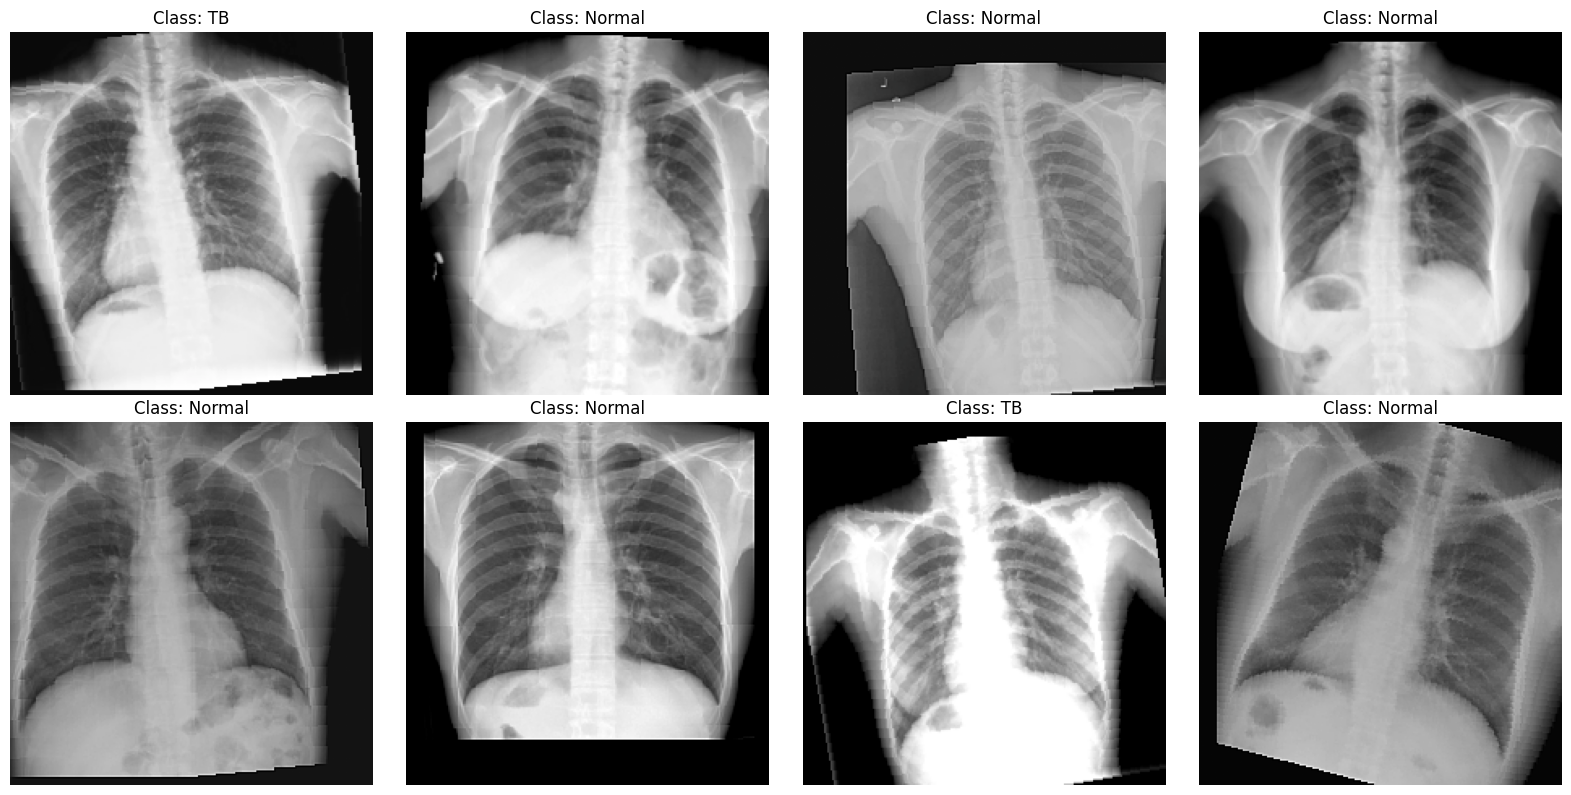

In [14]:
# CELL 8: Visualize Sample Images
# ============================================================================
def denormalize(tensor):
    """Denormalize image tensor for visualization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Visualize samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
train_iter = iter(train_loader)
images, labels_batch = next(train_iter)

for idx, ax in enumerate(axes.flat):
    img = denormalize(images[idx]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"Class: {config.CLASS_NAMES[labels_batch[idx]]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# CELL 9: Hybrid CNN-Transformer Model Architecture
# ============================================================================
class PatchEmbedding(nn.Module):
    """Convert feature maps to patch embeddings"""
    def __init__(self, in_channels=512, embed_dim=768, patch_size=7):
        super().__init__()
        self.patch_size = patch_size
        self.projection = nn.Conv2d(
            in_channels, 
            embed_dim, 
            kernel_size=patch_size, 
            stride=patch_size
        )
        
    def forward(self, x):
        # x shape: (B, C, H, W)
        x = self.projection(x)  # (B, embed_dim, H/patch_size, W/patch_size)
        x = x.flatten(2)  # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, embed_dim)
        return x

class TransformerBlock(nn.Module):
    """Transformer encoder block"""
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim, 
            num_heads, 
            dropout=dropout,
            batch_first=True
        )
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        
    def forward(self, x):
        # Multi-head self-attention
        attn_out, _ = self.attention(x, x, x)
        x = x + attn_out
        x = self.norm1(x)
        
        # MLP
        mlp_out = self.mlp(x)
        x = x + mlp_out
        x = self.norm2(x)
        
        return x

class HybridCNNTransformer(nn.Module):
    """Hybrid CNN-Transformer for TB Classification"""
    def __init__(self, config):
        super().__init__()
        
        # CNN Backbone (ResNet50 with transfer learning)
        self.backbone = models.resnet50(pretrained=True)
        
        # Freeze early layers (fine-tune later layers)
        for param in list(self.backbone.parameters())[:-30]:
            param.requires_grad = False
            
        # Remove the final FC layer
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(
            in_channels=2048,  # ResNet50 output channels
            embed_dim=config.EMBEDDING_DIM,
            patch_size=1
        )
        
        # Positional embedding
        self.num_patches = (config.IMG_SIZE // 32) ** 2  # After ResNet50
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, config.EMBEDDING_DIM)
        )
        
        # Class token
        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, config.EMBEDDING_DIM)
        )
        
        # Transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(
                config.EMBEDDING_DIM,
                config.NUM_HEADS,
                config.MLP_DIM,
                config.DROPOUT
            ) for _ in range(config.NUM_TRANSFORMER_BLOCKS)
        ])
        
        # Classification head
        self.norm = nn.LayerNorm(config.EMBEDDING_DIM)
        self.head = nn.Sequential(
            nn.Linear(config.EMBEDDING_DIM, 512),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(512, config.NUM_CLASSES)
        )
        
        # Initialize weights
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        
    def forward(self, x):
        B = x.shape[0]
        
        # CNN feature extraction
        x = self.backbone(x)  # (B, 2048, H/32, W/32)
        
        # Convert to patches
        x = self.patch_embed(x)  # (B, num_patches, embed_dim)
        
        # Add class token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        
        # Add positional embedding
        x = x + self.pos_embed
        
        # Transformer blocks
        for block in self.transformer_blocks:
            x = block(x)
        
        # Use class token for classification
        x = self.norm(x[:, 0])
        x = self.head(x)
        
        return x

# Create model
model = HybridCNNTransformer(config).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n{'='*60}")
print(f"Model: Hybrid CNN-Transformer")
print(f"{'='*60}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"{'='*60}\n")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s] 



Model: Hybrid CNN-Transformer
Total parameters: 47,573,058
Trainable parameters: 38,504,962



In [17]:
# CELL 10: Loss Function and Optimizer
# ============================================================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max', 
    factor=0.5, 
    patience=5, 
    # verbose=True
)

print("✓ Optimizer and scheduler configured")

✓ Optimizer and scheduler configured


In [18]:
# CELL 11: Training and Validation Functions
# ============================================================================
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        # Get predictions
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].detach().cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, epoch_auc

def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            # Get predictions
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, epoch_auc

print("✓ Training functions defined")


✓ Training functions defined


In [19]:
# CELL 12: Training Loop with Early Stopping
# ============================================================================
history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [],
    'val_loss': [], 'val_acc': [], 'val_auc': []
}

best_val_auc = 0.0
patience_counter = 0

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60 + "\n")

for epoch in range(config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{config.EPOCHS}")
    print("-" * 60)
    
    # Train
    train_loss, train_acc, train_auc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_acc, val_auc = validate_epoch(
        model, val_loader, criterion, device
    )
    
    # Update learning rate
    scheduler.step(val_auc)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    
    # Print metrics
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train AUC: {train_auc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val AUC:   {val_auc:.4f}")
    
    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ Best model saved! (Val AUC: {val_auc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        
    # Early stopping
    if patience_counter >= config.EARLY_STOPPING_PATIENCE:
        print(f"\n⚠ Early stopping triggered after {epoch+1} epochs")
        break

print("\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)



STARTING TRAINING


Epoch 1/50
------------------------------------------------------------


Validation: 100%|██████████| 12/12 [00:13<00:00,  1.16s/it, loss=0.294]



Train Loss: 0.4747 | Train Acc: 0.7695 | Train AUC: 0.8537
Val Loss:   0.3210 | Val Acc:   0.9164 | Val AUC:   0.9691
✓ Best model saved! (Val AUC: 0.9691)

Epoch 2/50
------------------------------------------------------------


Validation: 100%|██████████| 12/12 [00:11<00:00,  1.03it/s, loss=0.104]



Train Loss: 0.3432 | Train Acc: 0.8599 | Train AUC: 0.9237
Val Loss:   0.2344 | Val Acc:   0.8997 | Val AUC:   0.9657

Epoch 3/50
------------------------------------------------------------


...


Train Loss: 0.0603 | Train Acc: 0.9754 | Train AUC: 0.9979
Val Loss:   0.1197 | Val Acc:   0.9610 | Val AUC:   0.9933

Epoch 49/50
------------------------------------------------------------


Validation: 100%|██████████| 12/12 [00:11<00:00,  1.03it/s, loss=0.719] 



Train Loss: 0.0554 | Train Acc: 0.9760 | Train AUC: 0.9982
Val Loss:   0.1204 | Val Acc:   0.9638 | Val AUC:   0.9937

Epoch 50/50
------------------------------------------------------------


Validation: 100%|██████████| 12/12 [00:11<00:00,  1.02it/s, loss=0.582] 


Train Loss: 0.0554 | Train Acc: 0.9760 | Train AUC: 0.9982
Val Loss:   0.1258 | Val Acc:   0.9582 | Val AUC:   0.9934

TRAINING COMPLETED


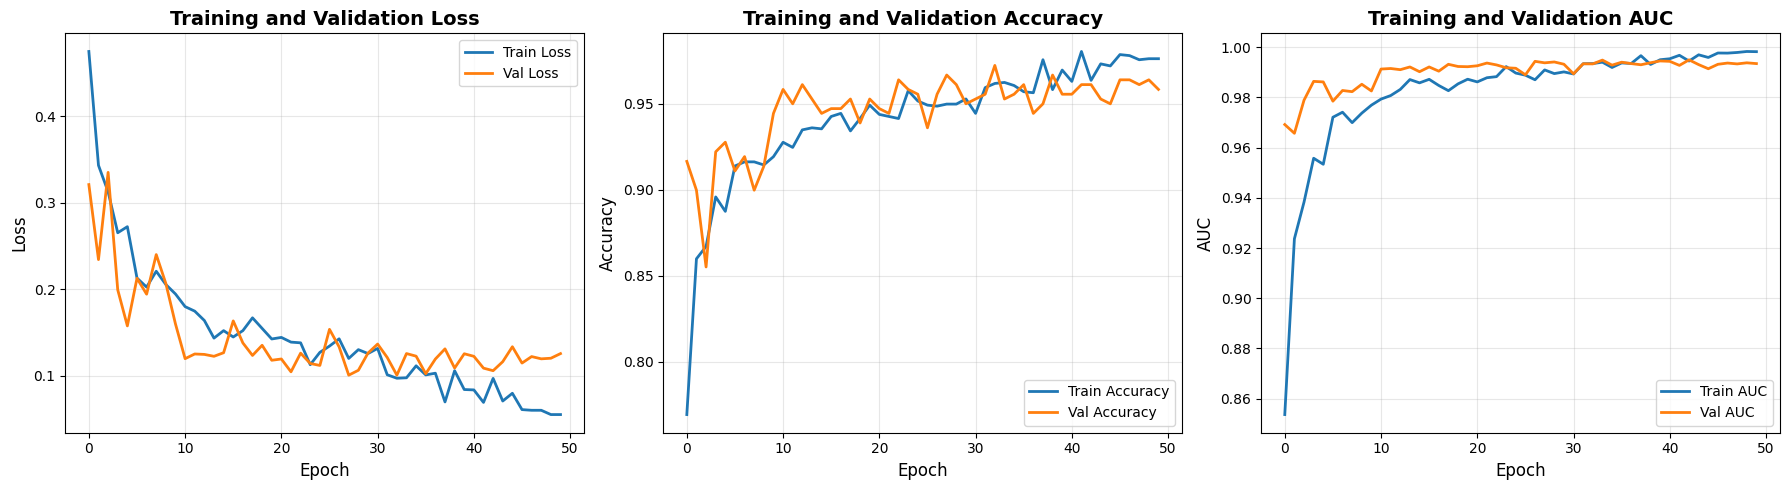

In [20]:
# CELL 13: Plot Training History
# ============================================================================
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot Loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Plot Accuracy
    axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    # Plot AUC
    axes[2].plot(history['train_auc'], label='Train AUC', linewidth=2)
    axes[2].plot(history['val_auc'], label='Val AUC', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('AUC', fontsize=12)
    axes[2].set_title('Training and Validation AUC', fontsize=14, fontweight='bold')
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)


In [21]:
# CELL 14: Load Best Model and Evaluate on Test Set
# ============================================================================
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60 + "\n")

test_loss, test_acc, test_auc = validate_epoch(
    model, test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")



EVALUATING ON TEST SET



Validation: 100%|██████████| 12/12 [00:12<00:00,  1.03s/it, loss=0.00185]

Test Loss: 0.1696
Test Accuracy: 0.9304
Test AUC: 0.9860


In [22]:
# CELL 15: Detailed Test Set Evaluation
# ============================================================================
def evaluate_model(model, loader, device):
    """Comprehensive model evaluation"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Get predictions
y_true, y_pred, y_prob = evaluate_model(model, test_loader, device)

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60 + "\n")
print(classification_report(
    y_true, y_pred, 
    target_names=config.CLASS_NAMES, 
    digits=4
))


Evaluating: 100%|██████████| 12/12 [00:10<00:00,  1.14it/s]


CLASSIFICATION REPORT

              precision    recall  f1-score   support

      Normal     0.9101    0.9556    0.9322       180
          TB     0.9529    0.9050    0.9284       179

    accuracy                         0.9304       359
   macro avg     0.9315    0.9303    0.9303       359
weighted avg     0.9314    0.9304    0.9303       359



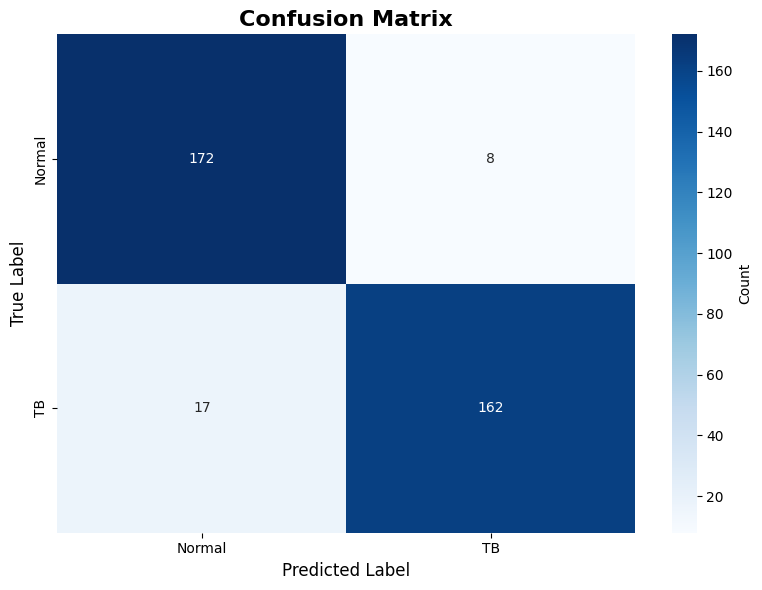

In [23]:
# CELL 16: Confusion Matrix
# ============================================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=config.CLASS_NAMES,
    yticklabels=config.CLASS_NAMES,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

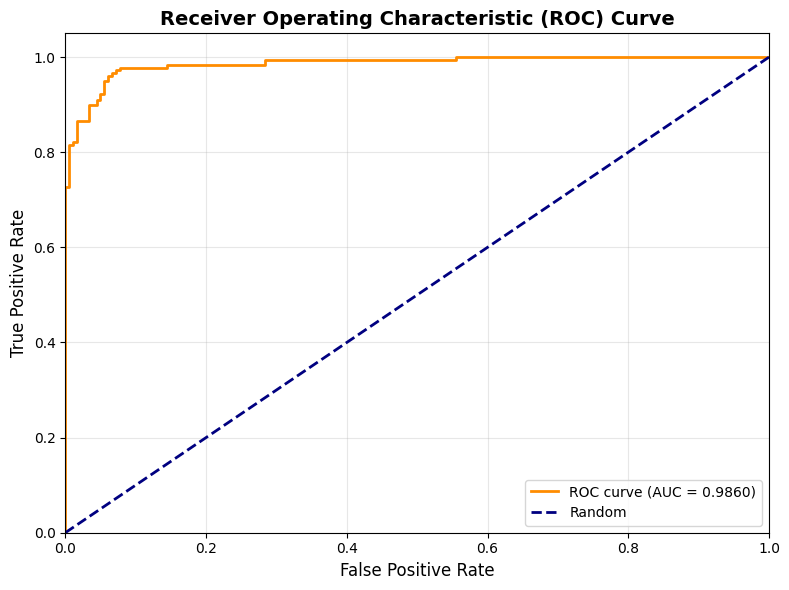

In [24]:
# CELL 17: ROC Curve
# ============================================================================
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', 
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# CELL 18: GradCAM Implementation
# ============================================================================
class GradCAMWrapper:
    """Wrapper for GradCAM visualization"""
    def __init__(self, model, target_layer):
        self.model = model
        self.gradcam = GradCAM(model=model, target_layers=[target_layer])
        
    def generate_cam(self, input_tensor, target_class=None):
        """Generate CAM for input image"""
        targets = [ClassifierOutputTarget(target_class)] if target_class is not None else None
        grayscale_cam = self.gradcam(input_tensor=input_tensor, targets=targets)
        return grayscale_cam[0]

# Initialize GradCAM with the last CNN layer
target_layer = model.backbone[-1][-1].conv3  # Last conv layer of ResNet50
gradcam_wrapper = GradCAMWrapper(model, target_layer)

print("✓ GradCAM initialized")

✓ GradCAM initialized


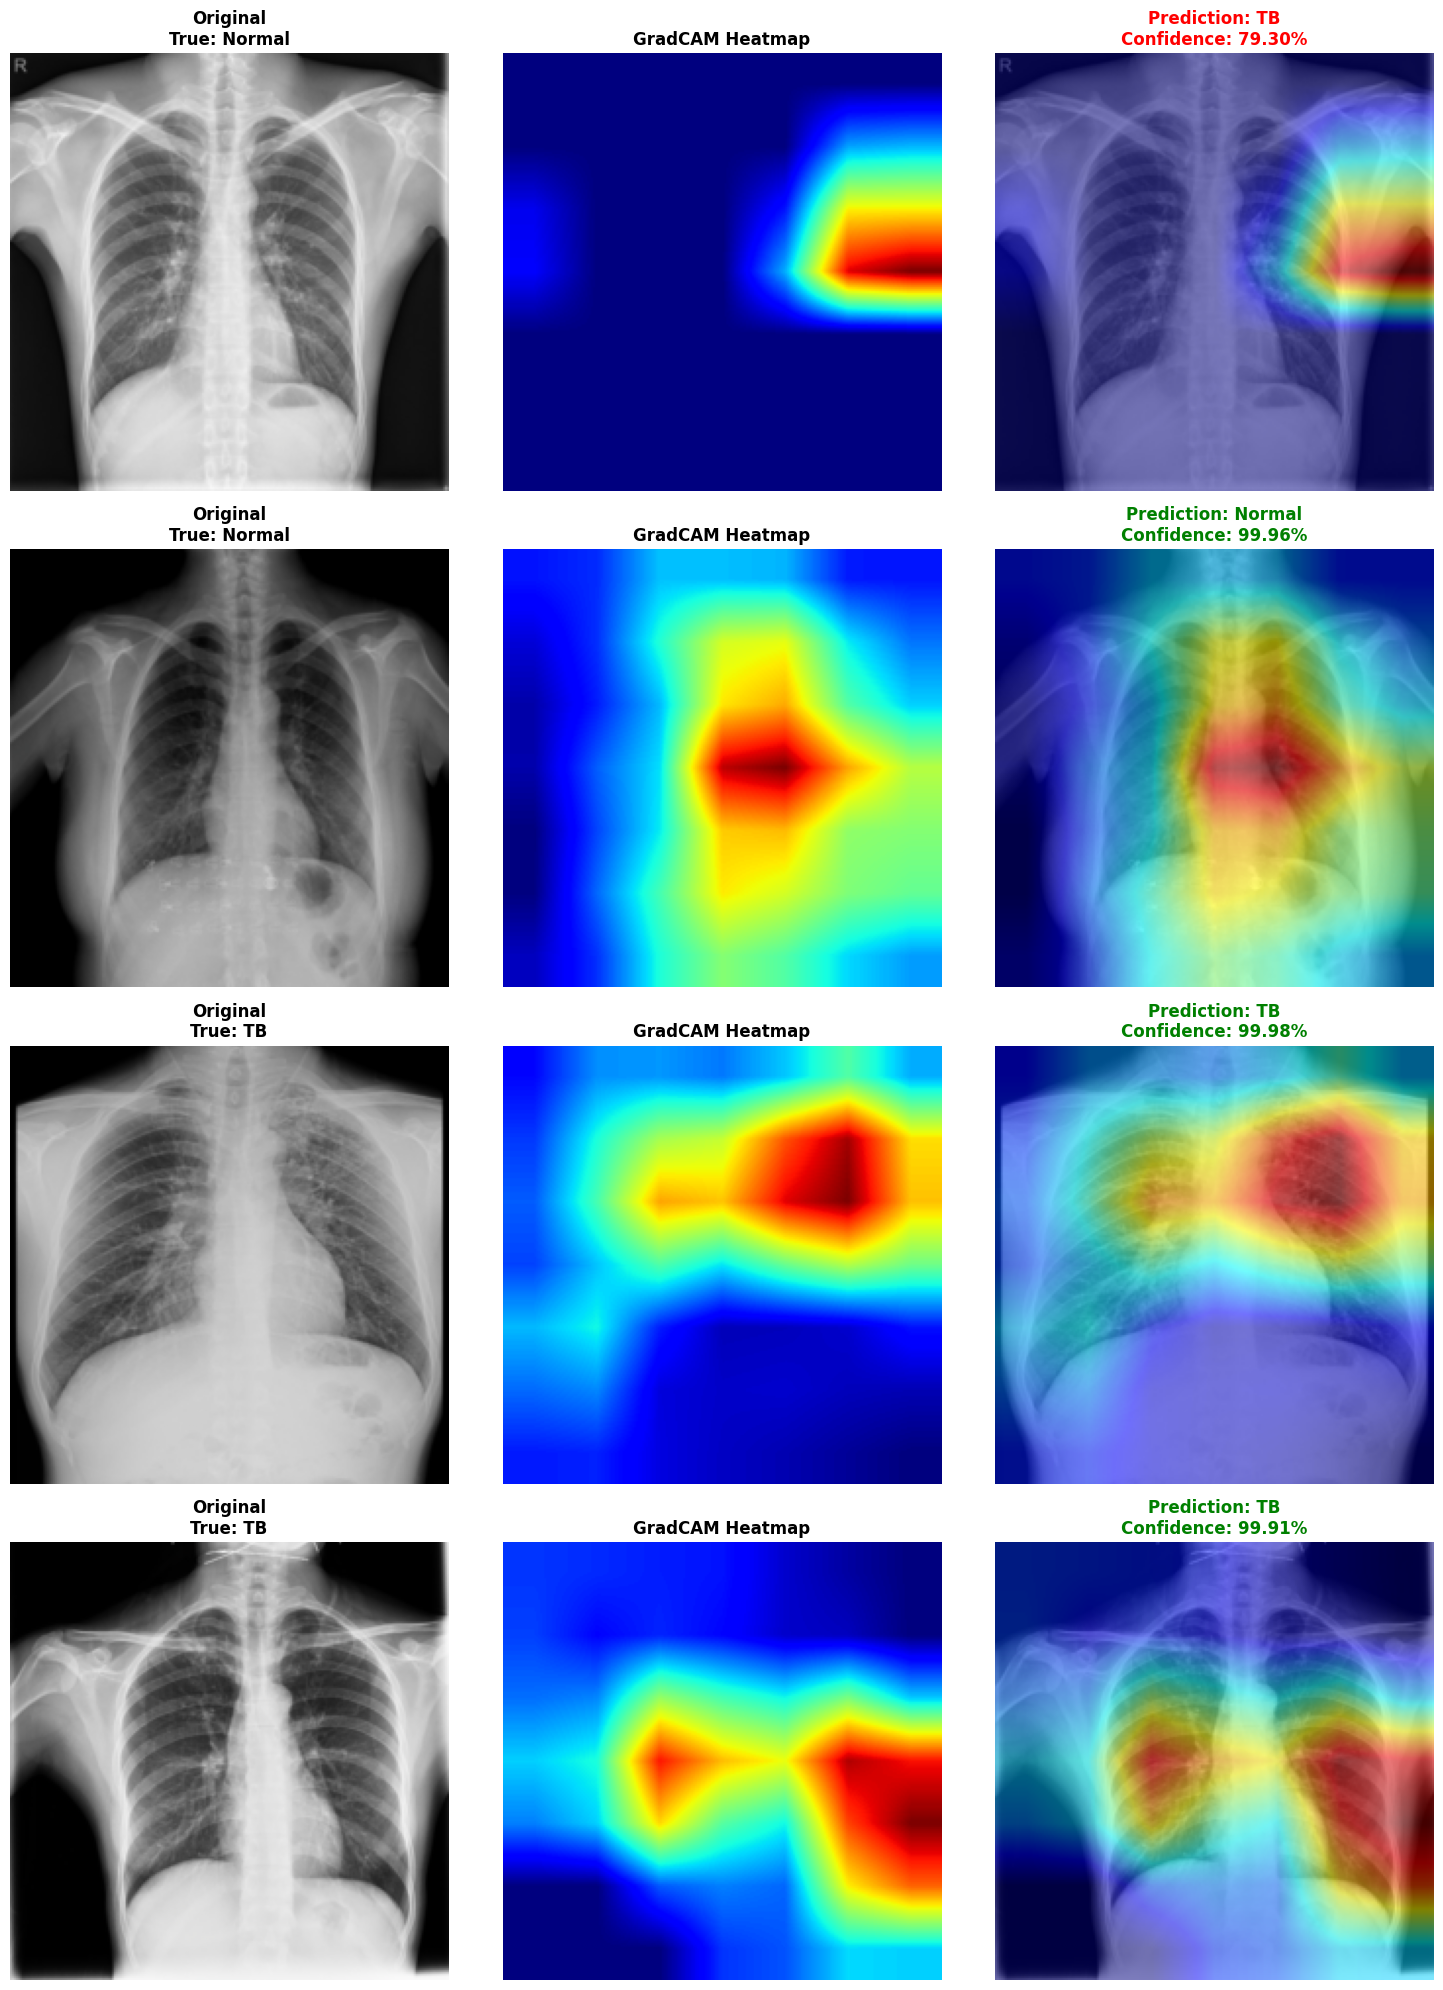

In [26]:
# CELL 19: Visualize GradCAM on Test Samples
# ============================================================================
def visualize_gradcam(model, gradcam_wrapper, dataset, indices, device, save_path='gradcam_results.png'):
    """Visualize GradCAM for multiple samples"""
    model.eval()
    
    fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5*len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        # Get image and label
        img_tensor, true_label = dataset[idx]
        img_tensor_batch = img_tensor.unsqueeze(0).to(device)
        
        # Get prediction
        with torch.no_grad():
            output = model(img_tensor_batch)
            prob = F.softmax(output, dim=1)
            pred_label = torch.argmax(output, dim=1).item()
            confidence = prob[0, pred_label].item()
        
        # Denormalize image for visualization
        img_denorm = denormalize(img_tensor).permute(1, 2, 0).numpy()
        img_denorm = np.clip(img_denorm, 0, 1)
        
        # Generate GradCAM
        cam = gradcam_wrapper.generate_cam(img_tensor_batch, target_class=pred_label)
        cam_image = show_cam_on_image(img_denorm, cam, use_rgb=True)
        
        # Plot original image
        axes[i, 0].imshow(img_denorm)
        axes[i, 0].set_title(f'Original\nTrue: {config.CLASS_NAMES[true_label]}', 
                            fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Plot GradCAM heatmap
        axes[i, 1].imshow(cam, cmap='jet')
        axes[i, 1].set_title(f'GradCAM Heatmap', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Plot overlay
        axes[i, 2].imshow(cam_image)
        axes[i, 2].set_title(
            f'Prediction: {config.CLASS_NAMES[pred_label]}\nConfidence: {confidence:.2%}', 
            fontsize=12, fontweight='bold',
            color='green' if pred_label == true_label else 'red'
        )
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Select random samples from test set (both classes)
normal_indices = [i for i, label in enumerate(y_test) if label == 0]
tb_indices = [i for i, label in enumerate(y_test) if label == 1]

sample_indices = [
    np.random.choice(normal_indices),
    np.random.choice(normal_indices),
    np.random.choice(tb_indices),
    np.random.choice(tb_indices)
]

visualize_gradcam(model, gradcam_wrapper, test_dataset, sample_indices, device)


In [27]:
# CELL 20: Interactive GradCAM Function for Single Image
# ============================================================================
def predict_with_gradcam(image_path, model, gradcam_wrapper, transform, device):
    """Predict and visualize GradCAM for a single image"""
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(device)
    
    # Get prediction
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        prob = F.softmax(output, dim=1)
        pred_label = torch.argmax(output, dim=1).item()
        confidence = prob[0, pred_label].item()
    
    # Generate GradCAM
    cam = gradcam_wrapper.generate_cam(img_tensor, target_class=pred_label)
    
    # Prepare image for visualization
    img_denorm = denormalize(img_tensor.squeeze(0).cpu()).permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_denorm, 0, 1)
    cam_image = show_cam_on_image(img_denorm, cam, use_rgb=True)
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_denorm)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('GradCAM Heatmap', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(cam_image)
    axes[2].set_title(
        f'Prediction: {config.CLASS_NAMES[pred_label]}\nConfidence: {confidence:.2%}',
        fontsize=14, fontweight='bold'
    )
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig('single_prediction_gradcam.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return config.CLASS_NAMES[pred_label], confidence

# Example usage (uncomment and provide image path):
# pred_class, conf = predict_with_gradcam(
#     '/path/to/your/image.png', 
#     model, 
#     gradcam_wrapper, 
#     val_test_transforms, 
#     device
# )

print("✓ Interactive GradCAM function ready")


✓ Interactive GradCAM function ready


In [28]:
# CELL 21: Save Training History
# ============================================================================
history_df = pd.DataFrame(history)
history_df.to_csv('training_history.csv', index=False)
print("✓ Training history saved to 'training_history.csv'")


✓ Training history saved to 'training_history.csv'


In [29]:
# CELL 22: Model Summary and Final Results
# ============================================================================
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"\nArchitecture: Hybrid CNN-Transformer")
print(f"Backbone: ResNet50 (Transfer Learning)")
print(f"Transformer Blocks: {config.NUM_TRANSFORMER_BLOCKS}")
print(f"Embedding Dimension: {config.EMBEDDING_DIM}")
print(f"Attention Heads: {config.NUM_HEADS}")
print(f"\nDataset:")
print(f"  Total Images: {len(image_paths)}")
print(f"  Train: {len(X_train)}")
print(f"  Val: {len(X_val)}")
print(f"  Test: {len(X_test)}")
print(f"\nBest Validation AUC: {best_val_auc:.4f}")
print(f"\nTest Set Performance:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  AUC: {test_auc:.4f}")
print(f"  Loss: {test_loss:.4f}")
print("\n" + "="*60)



FINAL MODEL SUMMARY

Architecture: Hybrid CNN-Transformer
Backbone: ResNet50 (Transfer Learning)
Transformer Blocks: 4
Embedding Dimension: 768
Attention Heads: 8

Dataset:
  Total Images: 2388
  Train: 1670
  Val: 359
  Test: 359

Best Validation AUC: 0.9949

Test Set Performance:
  Accuracy: 0.9304
  AUC: 0.9860
  Loss: 0.1696



In [ ]:
p